In [1]:
!pip install pandas numpy matplotlib seaborn wordcloud nltk


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os

folders = [
    "images",
    "models",
    "data",
    "src"
]


for folder in folders:
    os.makedirs(folder, exist_ok=True)


print("Project folders created successfully!")

Project folders created successfully!


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("Resume.csv")

In [5]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [6]:
df.shape

(2484, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [8]:
missing = df.isnull().sum()

missing

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

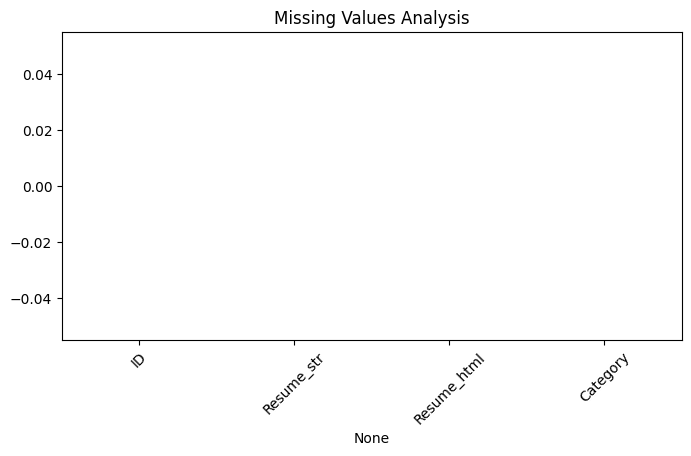

In [9]:
plt.figure(figsize=(8,4))


sns.barplot(
    x=missing.index,
    y=missing.values
)


plt.title(
    "Missing Values Analysis"
)

plt.xticks(rotation=45)


plt.savefig(
    "images/missing_values.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [10]:
duplicates = df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicates
)

Duplicate rows: 0


In [11]:
df.drop_duplicates(
    inplace=True
)


print(
    "Duplicates removed"
)

Duplicates removed


In [12]:
print(
    "Total Categories:",
    df['Category'].nunique()
)

Total Categories: 24


In [13]:
category_count = (
    df['Category']
    .value_counts()
)


category_count.head(10)

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
Name: count, dtype: int64

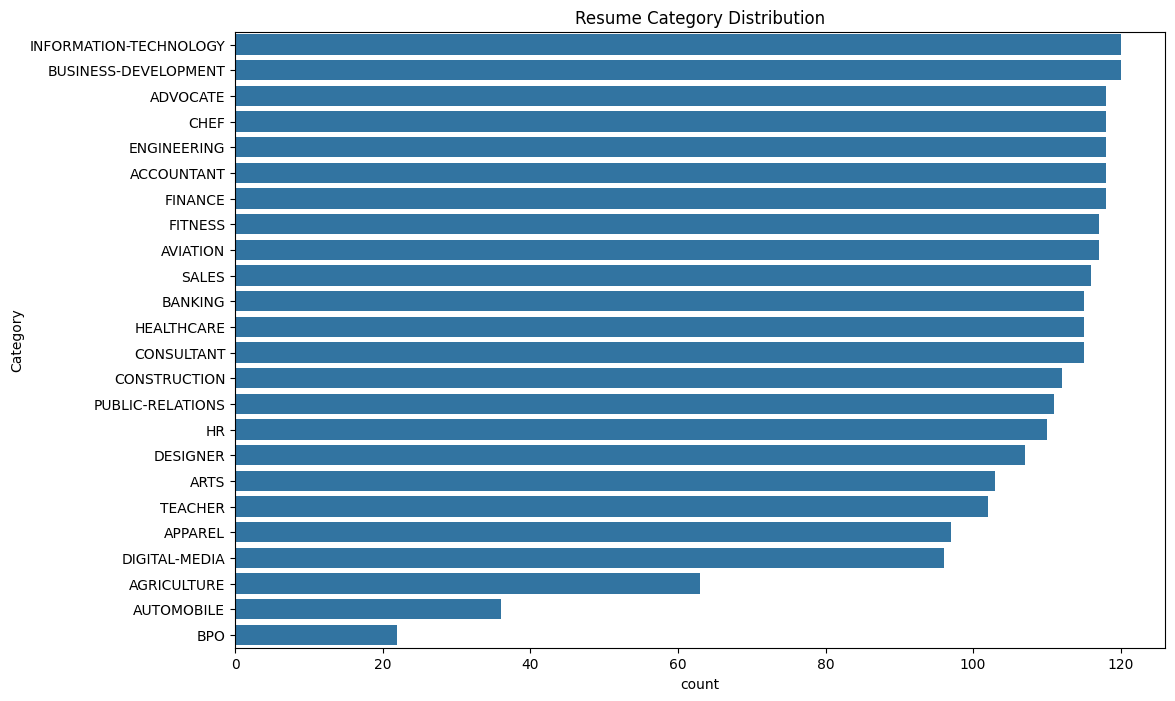

In [14]:
plt.figure(figsize=(12,8))


sns.countplot(
    y=df['Category'],
    order=df['Category'].value_counts().index
)


plt.title(
    "Resume Category Distribution"
)


plt.savefig(
    "images/category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [15]:
df['resume_length'] = (
    df['Resume_str']
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)

In [16]:
df[
[
'Category',
'resume_length'
]
].head()

,Category,resume_length
0,HR,674
1,HR,708
2,HR,1017
3,HR,379
4,HR,1206


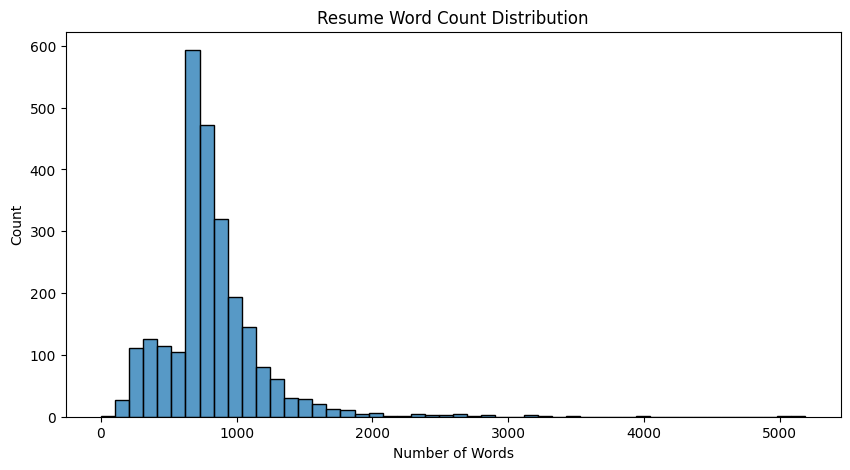

In [17]:
plt.figure(figsize=(10,5))


sns.histplot(
    df['resume_length'],
    bins=50
)


plt.title(
    "Resume Word Count Distribution"
)


plt.xlabel(
    "Number of Words"
)


plt.savefig(
    "images/resume_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

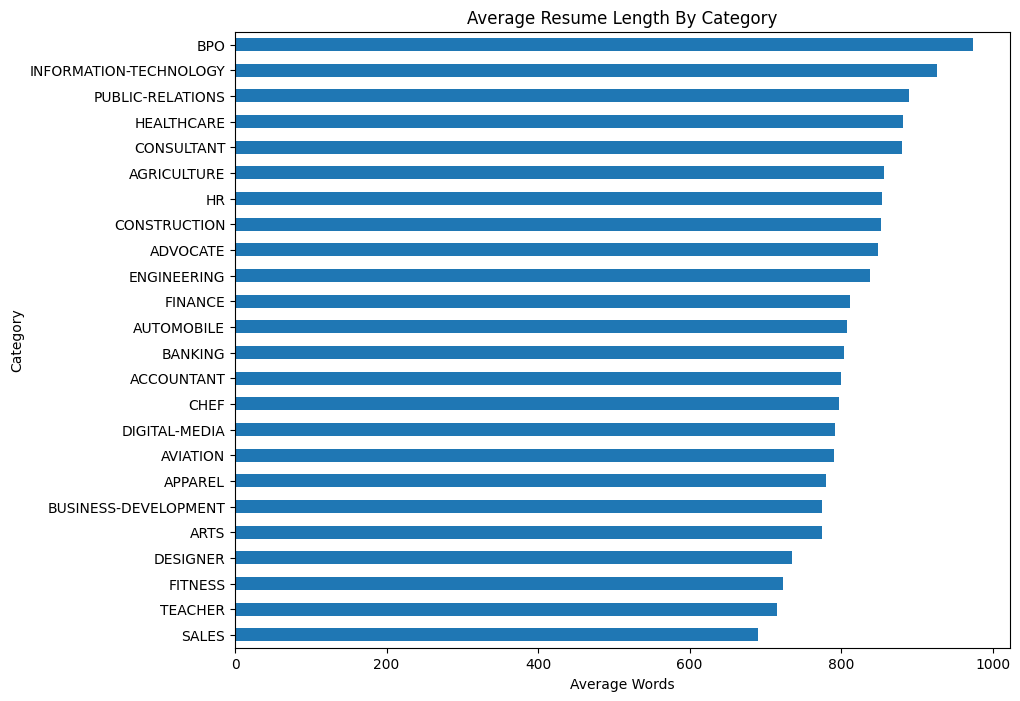

In [18]:
avg_length = (
    df.groupby('Category')
    ['resume_length']
    .mean()
    .sort_values()
)


plt.figure(figsize=(10,8))


avg_length.plot(
    kind='barh'
)


plt.title(
    "Average Resume Length By Category"
)


plt.xlabel(
    "Average Words"
)


plt.savefig(
    "images/category_resume_length.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [19]:
all_resume_text = " ".join(
    df['Resume_str']
    .astype(str)
)

In [20]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(
    all_resume_text
)

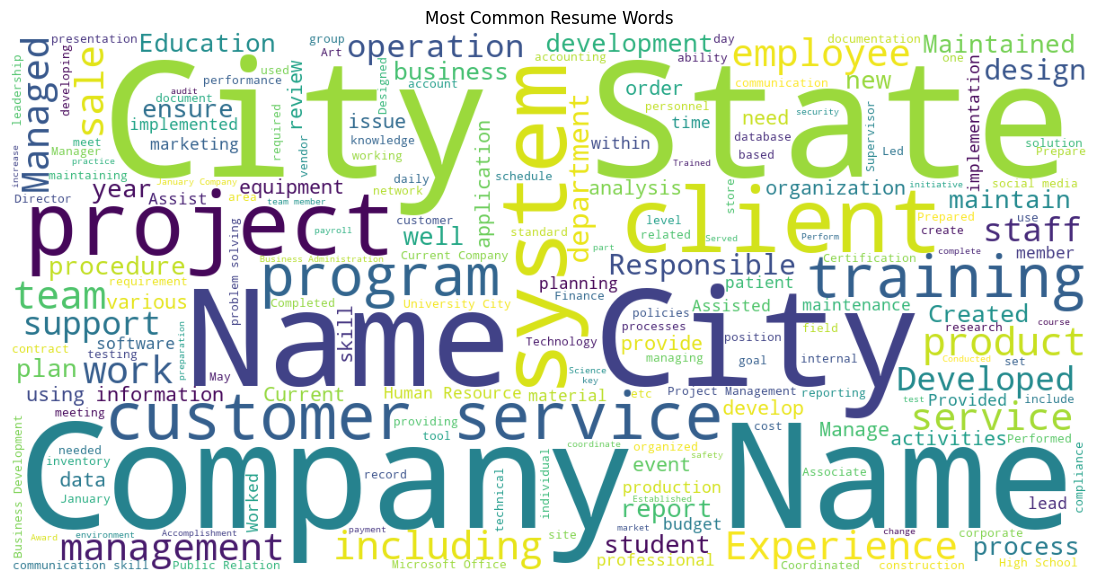

In [21]:
plt.figure(figsize=(15,7))


plt.imshow(
    wordcloud
)


plt.axis("off")


plt.title(
    "Most Common Resume Words"
)


plt.savefig(
    "images/resume_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [22]:
skills = [
    "python",
    "java",
    "sql",
    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",
    "aws",
    "azure",
    "docker",
    "excel",
    "power bi",
    "tableau",
    "nlp",
    "data analysis"
]

In [23]:
skill_count={}


resume_text = (
    df['Resume_str']
    .astype(str)
    .str.lower()
)


for skill in skills:

    count = (
        resume_text
        .str.contains(skill)
        .sum()
    )

    skill_count[skill]=count


skill_df = pd.DataFrame(
    skill_count.items(),
    columns=[
        "Skill",
        "Count"
    ]
)


skill_df.sort_values(
    by="Count",
    ascending=False
)

,Skill,Count
10,excel,1616
7,aws,302
2,sql,191
14,data analysis,126
1,java,98
0,python,40
12,tableau,26
3,machine learning,12
8,azure,11
5,tensorflow,3


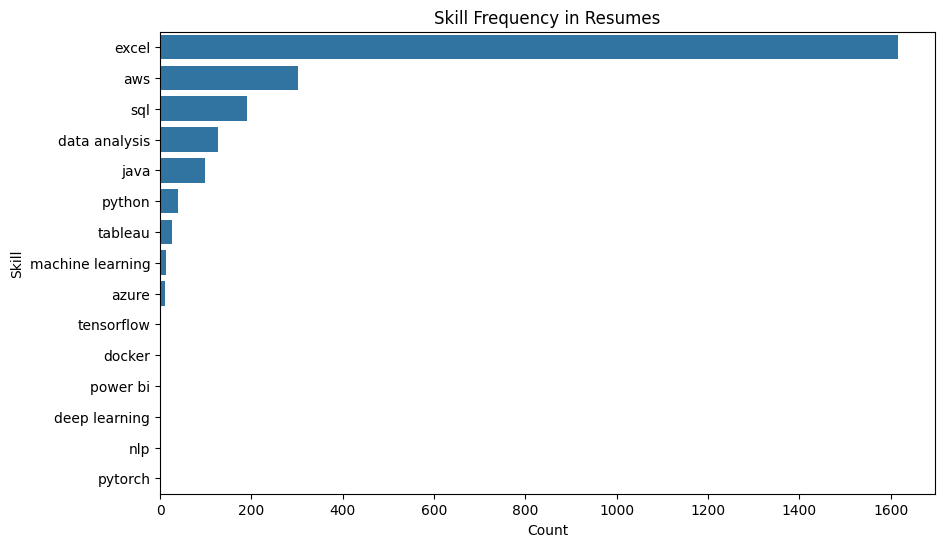

In [24]:
plt.figure(figsize=(10,6))


sns.barplot(
    data=skill_df.sort_values(
        "Count",
        ascending=False
    ),
    x="Count",
    y="Skill"
)


plt.title(
    "Skill Frequency in Resumes"
)


plt.savefig(
    "images/skill_frequency.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [25]:
df.to_csv(
    "data/clean_resume_dataset.csv",
    index=False
)


print(
    "Clean dataset saved!"
)

Clean dataset saved!


In [26]:
!pip install nltk spacy beautifulsoup4 tqdm


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np

import re
import string

from bs4 import BeautifulSoup

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [28]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

print("NLTK resources downloaded successfully!")

NLTK resources downloaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [29]:
df = pd.read_csv(
    "data/clean_resume_dataset.csv"
)


df.head()

,ID,Resume_str,Resume_html,Category,resume_length
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,674
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,708
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,1017
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,379
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,1206


In [30]:
df['Resume_str'].iloc[0][:500]

'         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task'

In [31]:
def remove_html(text):
    
    soup = BeautifulSoup(
        text,
        "html.parser"
    )
    
    return soup.get_text()

In [32]:
def remove_urls(text):
    
    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )
    
    return text

In [33]:
def remove_special_chars(text):
    
    text = re.sub(
        '[^a-zA-Z]',
        ' ',
        text
    )
    
    return text

In [34]:
def remove_spaces(text):
    
    text = re.sub(
        '\s+',
        ' ',
        text
    )
    
    return text.strip()

In [35]:
stop_words = set(
    stopwords.words('english')
)

In [36]:
lemmatizer = WordNetLemmatizer()

In [37]:
def preprocess_text(text):

    # convert to string
    text = str(text)


    # lowercase
    text = text.lower()


    # remove html
    text = remove_html(text)


    # remove urls
    text = remove_urls(text)


    # remove special characters
    text = remove_special_chars(text)


    # remove spaces
    text = remove_spaces(text)


    # tokenize
    words = nltk.word_tokenize(text)


    cleaned_words = []


    for word in words:


        # remove stopwords
        if word not in stop_words:


            # lemmatization
            word = lemmatizer.lemmatize(word)


            cleaned_words.append(word)



    return " ".join(cleaned_words)

In [38]:
sample = df['Resume_str'][0]


print(
    "BEFORE:\n"
)

print(sample[:500])


print(
    "\n\nAFTER:\n"
)

print(
    preprocess_text(sample)[:500]
)

BEFORE:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task


AFTER:

hr administrator marketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfaction team management marketing savvy conflict resolution technique training development skilled multi tasker client relation specialist accomplishment missouri dot supervisor traini

In [39]:
tqdm.pandas()


df['clean_resume'] = (
    df['Resume_str']
    .progress_apply(
        preprocess_text
    )
)

100%|█████████████████████████████████████████████████████████████████████████████| 2484/2484 [00:17<00:00, 144.00it/s]


In [40]:
df[
[
'Resume_str',
'clean_resume'
]
].head()

,Resume_str,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist u hr operation summary versatile...
2,HR DIRECTOR Summary Over 2...,hr director summary year experience recruiting...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlight hr skill hr departm...


In [41]:
empty = (
    df['clean_resume']
    .apply(
        lambda x: len(x)==0
    )
    .sum()
)


print(
    "Empty resumes:",
    empty
)

Empty resumes: 1


In [42]:
df = df[
    df['clean_resume'].str.len()>0
]

In [43]:
df['clean_length'] = (
    df['clean_resume']
    .apply(
        lambda x: len(x.split())
    )
)

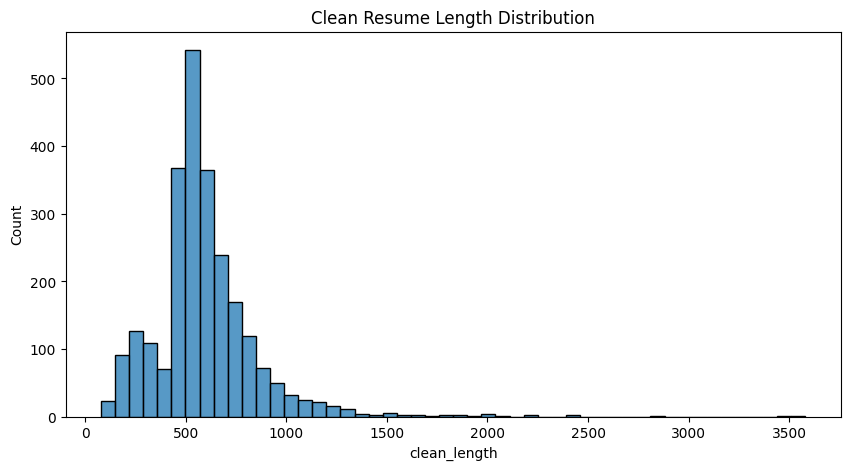

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10,5))


sns.histplot(
    df['clean_length'],
    bins=50
)


plt.title(
    "Clean Resume Length Distribution"
)


plt.savefig(
    "images/clean_resume_length.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [45]:
df.to_csv(
    "data/processed_resume_dataset.csv",
    index=False
)


print(
    "Processed dataset saved successfully!"
)

Processed dataset saved successfully!


In [46]:
import re
import nltk

from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


stop_words=set(
    stopwords.words('english')
)


lemmatizer=WordNetLemmatizer()



def preprocess_text(text):

    text=str(text)

    text=text.lower()


    soup=BeautifulSoup(
        text,
        "html.parser"
    )

    text=soup.get_text()


    text=re.sub(
        r'http\S+',
        '',
        text
    )


    text=re.sub(
        '[^a-zA-Z]',
        ' ',
        text
    )


    words=nltk.word_tokenize(text)


    words=[
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]


    return " ".join(words)

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


import pickle

import warnings
warnings.filterwarnings("ignore")

In [48]:
df = pd.read_csv(
    "data/processed_resume_dataset.csv"
)


df.head()

,ID,Resume_str,Resume_html,Category,resume_length,clean_resume,clean_length
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,674,hr administrator marketing associate hr admini...,500
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,708,hr specialist u hr operation summary versatile...,536
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,1017,hr director summary year experience recruiting...,712
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,379,hr specialist summary dedicated driven dynamic...,262
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,1206,hr manager skill highlight hr skill hr departm...,885


In [49]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'resume_length',
       'clean_resume', 'clean_length'],
      dtype='object')

In [50]:
X = df['clean_resume']

In [51]:
y = df['Category']

In [52]:
y.value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    sublinear_tf=True
)

In [55]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)


X_test_tfidf = tfidf.transform(
    X_test
)

In [56]:
X_train_tfidf.shape

(1986, 15000)

In [57]:
with open(
    "models/tfidf_vectorizer.pkl",
    "wb"
) as file:

    pickle.dump(
        tfidf,
        file
    )


print(
    "TF-IDF Vectorizer saved!"
)

TF-IDF Vectorizer saved!


In [58]:
from sklearn.svm import LinearSVC


model = LinearSVC(
    class_weight="balanced"
)

In [59]:
model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [60]:
with open(
    "models/resume_classifier.pkl",
    "wb"
) as file:

    pickle.dump(
        model,
        file
    )


print(
    "Classifier saved successfully!"
)

Classifier saved successfully!


In [61]:
sample_resume = """
Python developer with experience in
machine learning, SQL, pandas,
TensorFlow and data analysis.
"""

In [62]:
sample_vector = tfidf.transform(
    [sample_resume]
)

In [63]:
prediction = model.predict(
    sample_vector
)


print(
    "Predicted Category:",
    prediction[0]
)

Predicted Category: ENGINEERING


In [64]:
y_pred = model.predict(
    X_test_tfidf
)

In [65]:
accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.7203219315895373


In [66]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                        precision    recall  f1-score   support

            ACCOUNTANT       0.69      0.83      0.75        24
              ADVOCATE       0.61      0.58      0.60        24
           AGRICULTURE       0.82      0.69      0.75        13
               APPAREL       0.58      0.37      0.45        19
                  ARTS       0.67      0.48      0.56        21
            AUTOMOBILE       1.00      0.43      0.60         7
              AVIATION       0.86      0.79      0.83        24
               BANKING       0.86      0.78      0.82        23
                   BPO       0.33      0.25      0.29         4
  BUSINESS-DEVELOPMENT       0.69      0.83      0.75        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.74      0.77      0.76        22
            CONSULTANT       0.75      0.39      0.51        23
              DESIGNER       0.90      0.90      0.90        21
         DIGITAL-MEDIA       0.71      

In [67]:
cm = confusion_matrix(
    y_test,
    y_pred
)

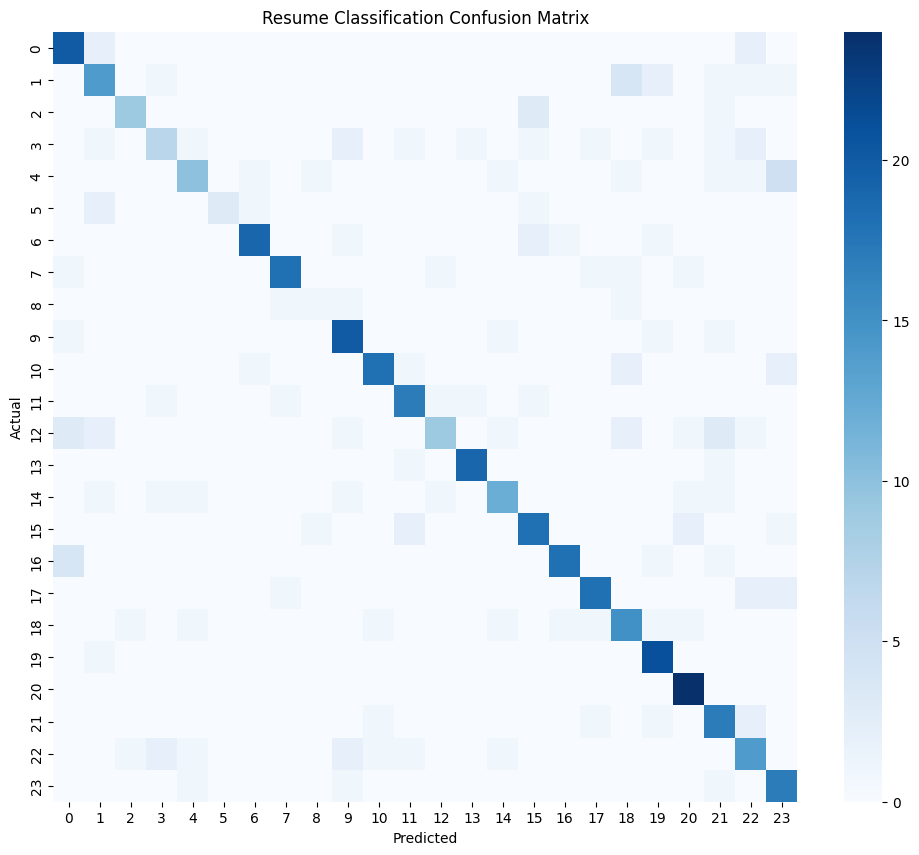

In [68]:
plt.figure(figsize=(12,10))


sns.heatmap(
    cm,
    cmap="Blues"
)


plt.title(
    "Resume Classification Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.savefig(
    "images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [69]:
metrics = {

"accuracy":accuracy

}


import json


with open(
    "models/model_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [70]:
import pickle


pickle.dump(
    model,
    open(
        "models/resume_classifier.pkl",
        "wb"
    )
)


pickle.dump(
    tfidf,
    open(
        "models/tfidf_vectorizer.pkl",
        "wb"
    )
)


print("Final models saved successfully!")

Final models saved successfully!


In [71]:
import os

folders = [
    "uploads",
    "reports",
    "src"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [72]:
!pip install pymupdf python-docx reportlab


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
import fitz
import docx


class ResumeParser:

    @staticmethod
    def read_pdf(file_path):

        text = ""

        pdf = fitz.open(file_path)

        for page in pdf:
            text += page.get_text()

        pdf.close()

        return text


    @staticmethod
    def read_docx(file_path):

        document = docx.Document(file_path)

        text = []

        for para in document.paragraphs:
            text.append(para.text)

        return "\n".join(text)


    @staticmethod
    def extract_text(file_path):

        extension = file_path.split(".")[-1].lower()

        if extension == "pdf":
            return ResumeParser.read_pdf(file_path)

        elif extension == "docx":
            return ResumeParser.read_docx(file_path)

        else:
            raise ValueError("Only PDF and DOCX are supported.")

In [74]:
from src.parser import ResumeParser

resume_text = ResumeParser.extract_text(
    "uploads/Kanan_Mundra (2).pdf"
)

print(resume_text[:1500])

Kanan Mundra
+91-8824235688 — kananmundra06@gmail.com — LinkedIn — GitHub
Professional Summary
Aspiring Data Scientist pursuing a B.Tech in Computer Science with expertise in Machine Learning, Data Analytics, Natural
Language Processing, and Data Visualization. Skilled in Python, SQL, Scikit-learn, Tableau, Power BI, and Generative AI,
with hands-on experience building predictive models and AI-driven applications using real-world datasets.
Education
Banasthali Vidyapith
Rajasthan, India
Bachelor of Technology in Computer Science & Engineering
2023 – 2027
– Relevant Coursework: Machine Learning, Data Mining, Database Management Systems, Artificial Intelligence, Statistics, Data
Structures
Experience
Data Analytics Intern
May 2024 – Jul 2024
Tally Solutions Pvt. Ltd.
– Built time-series forecasting models to predict sales trends and support business decision-making.
– Developed interactive Tableau dashboards to visualize KPIs and customer support analytics.
– Performed data preprocessing

In [75]:
from src.resume_analyzer import ResumeAnalyzer

result = ResumeAnalyzer.analyze(
    "uploads/Kanan_Mundra (2).pdf"
)

for key, value in result.items():

    if key != "Raw Text":
        print(f"{key}: {value}")

Name: Kanan Mundra
Email: kananmundra06@gmail.com
Phone: +91-8824235688
LinkedIn: None
GitHub: None
Skills: ['Azure', 'Data Analysis', 'Git', 'Github', 'Machine Learning', 'Nlp', 'Numpy', 'Pandas', 'Power Bi', 'Python', 'Scikit-Learn', 'Sql', 'Statistics', 'Streamlit', 'Tableau']
Resume Length: 439


In [76]:
from src.skill_extractor import extract_skills

skills = extract_skills(resume_text)

print(skills)

['Azure', 'Data Analysis', 'Git', 'Github', 'Machine Learning', 'Nlp', 'Numpy', 'Pandas', 'Power Bi', 'Python', 'Scikit-Learn', 'Sql', 'Statistics', 'Streamlit', 'Tableau']


In [77]:
from src.resume_analyzer import ResumeAnalyzer

resume_result = ResumeAnalyzer.analyze(
    "uploads/Kanan_Mundra (2).pdf"
)

print(resume_result.keys())

dict_keys(['Name', 'Email', 'Phone', 'LinkedIn', 'GitHub', 'Skills', 'Resume Length', 'Raw Text'])


In [78]:
from src.resume_analyzer import ResumeAnalyzer

resume_result = ResumeAnalyzer.analyze(
    "uploads/Kanan_Mundra (2).pdf"
)

print("Skills Found:")

for skill in result["Skills"]:
    print("✓", skill)

Skills Found:
✓ Azure
✓ Data Analysis
✓ Git
✓ Github
✓ Machine Learning
✓ Nlp
✓ Numpy
✓ Pandas
✓ Power Bi
✓ Python
✓ Scikit-Learn
✓ Sql
✓ Statistics
✓ Streamlit
✓ Tableau


In [79]:
print(result.keys())

dict_keys(['Name', 'Email', 'Phone', 'LinkedIn', 'GitHub', 'Skills', 'Resume Length', 'Raw Text'])


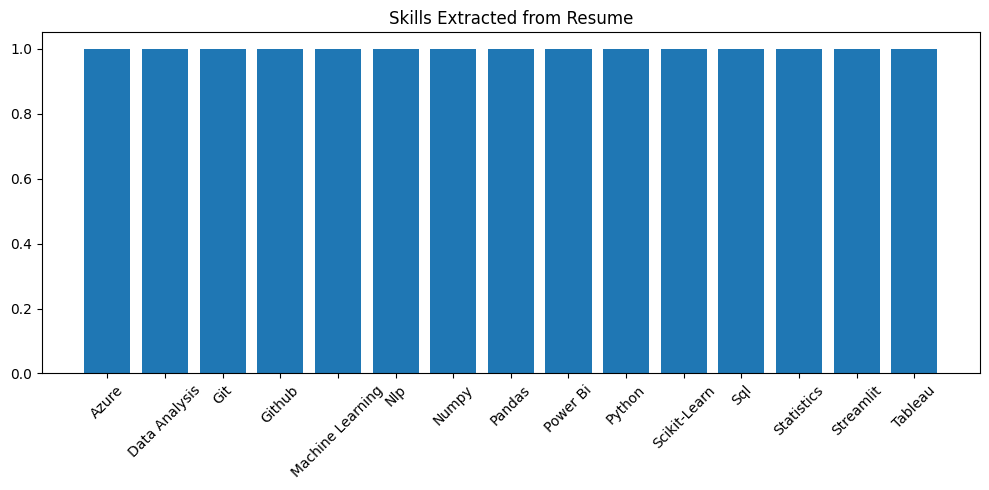

In [80]:
import matplotlib.pyplot as plt

skills = result["Skills"]

plt.figure(figsize=(10,5))

plt.bar(skills, [1]*len(skills))

plt.xticks(rotation=45)

plt.title("Skills Extracted from Resume")

plt.tight_layout()

plt.savefig(
    "images/resume_skills.png",
    dpi=300
)

plt.show()

In [81]:
from src.jd_parser import JobDescriptionParser

job_description = """
We are hiring a Data Scientist.

Requirements:

Python

SQL

Machine Learning

AWS

Docker

Power BI

Bachelor Degree

2+ years experience.
"""

result = JobDescriptionParser.analyze(job_description)

print(result)

{'Job Title': 'Data Scientist', 'Skills': ['Aws', 'Docker', 'Machine Learning', 'Power Bi', 'Python', 'Sql'], 'Experience': 2, 'Education': ['Bachelor']}


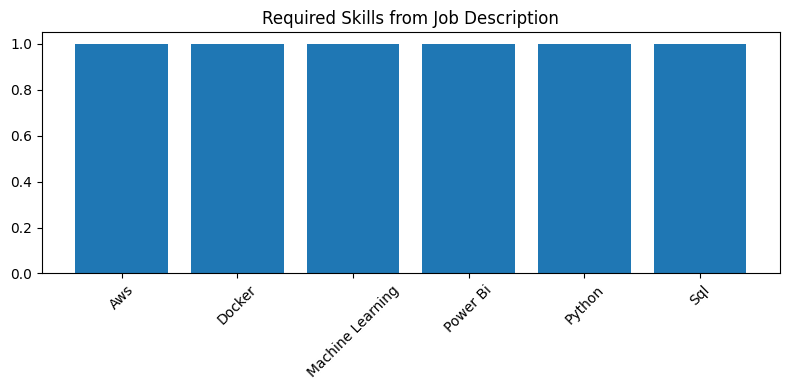

In [82]:
import matplotlib.pyplot as plt

skills = result["Skills"]

plt.figure(figsize=(8,4))

plt.bar(skills, [1] * len(skills))

plt.xticks(rotation=45)

plt.title("Required Skills from Job Description")

plt.tight_layout()

plt.savefig(
    "images/job_description_skills.png",
    dpi=300
)

plt.show()

In [83]:
!pip install sentence-transformers


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
import sentence_transformers

print("Sentence Transformers Installed Successfully!")

Sentence Transformers Installed Successfully!


In [85]:
from src.similarity import ResumeMatcher

matcher = ResumeMatcher()

resume = """
Python SQL Machine Learning
Power BI Tableau
Developed predictive models.
"""

job = """
Looking for a Data Scientist.

Python

SQL

Machine Learning

AWS

Docker
"""

score = matcher.calculate_similarity(
    resume,
    job
)

print(
    "Similarity Score:",
    score,
    "%"
)

Similarity Score: 52.09 %


In [86]:
from src.parser import ResumeParser
from src.similarity import ResumeMatcher

resume_text = ResumeParser.extract_text(
    "uploads/Kanan_Mundra (2).pdf"
)

matcher = ResumeMatcher()

job_description = """
Data Scientist

Python

SQL

Machine Learning

Power BI

Azure

Docker

2 years experience
"""

semantic_score = matcher.calculate_similarity(
    resume_text,
    job_description
)


print(score)

52.09


In [87]:
result["Semantic Similarity"] = score

print(result)

{'Job Title': 'Data Scientist', 'Skills': ['Aws', 'Docker', 'Machine Learning', 'Power Bi', 'Python', 'Sql'], 'Experience': 2, 'Education': ['Bachelor'], 'Semantic Similarity': np.float32(52.09)}


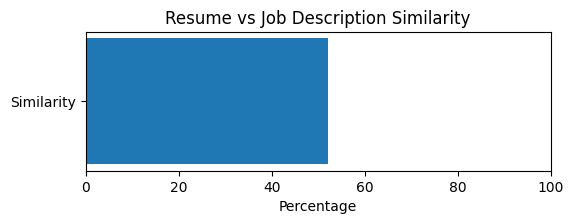

In [88]:
import matplotlib.pyplot as plt

score = score

plt.figure(figsize=(6, 1.8))

plt.barh(
    ["Similarity"],
    [score]
)

plt.xlim(0,100)

plt.xlabel("Percentage")

plt.title("Resume vs Job Description Similarity")

plt.savefig(
    "images/similarity_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
from src.jd_parser import JobDescriptionParser

job_description = """
We are hiring a Data Scientist.

Requirements:
- Python
- SQL
- Machine Learning
- AWS
- Docker
- Power BI

Experience:
2+ years

Education:
Bachelor Degree in Computer Science
"""

jd_result = JobDescriptionParser.analyze(job_description)

print(jd_result)

{'Job Title': 'Data Scientist', 'Skills': ['Aws', 'Docker', 'Machine Learning', 'Power Bi', 'Python', 'Sql'], 'Experience': 2, 'Education': ['Bachelor']}


In [90]:
# Resume skills extracted by your analyzer
resume_skills = result["Skills"]

# Experience (for now, manually set because we haven't built automatic extraction yet)
resume_years = 0

# Education (for now, manually set)
resume_education = ["Bachelor"]

In [92]:
from src.ats_score import ATSScorer

ats_result = ATSScorer.calculate_final_score(

    semantic_similarity=semantic_score,

    resume_skills=resume_result["Skills"],

    jd_skills=jd_result["Skills"],

    resume_years=0,

    jd_years=jd_result["Experience"],

    resume_education=["Bachelor"],

    jd_education=jd_result["Education"],

    result=resume_result
)

print(ats_result)

{'Matched Skills': [{'JD Skill': 'Machine Learning', 'Resume Skill': 'Machine Learning', 'Similarity': 100.0}, {'JD Skill': 'Power Bi', 'Resume Skill': 'Power Bi', 'Similarity': 100.0}, {'JD Skill': 'Python', 'Resume Skill': 'Python', 'Similarity': 100.0}, {'JD Skill': 'Sql', 'Resume Skill': 'Sql', 'Similarity': 100.0}], 'Matched Skill Count': 4, 'Missing Skills': ['Aws', 'Docker'], 'Skill Match': 60.0, 'Semantic Similarity': 51.79, 'Experience Score': 100, 'Education Score': 100, 'Project Score': 100, 'Certification Score': 50, 'Achievement Score': 72, 'Resume Completeness': 70, 'Final ATS Score': 71.46}


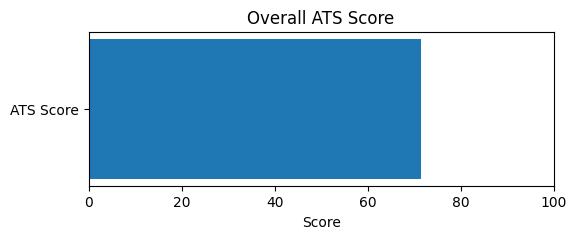

In [93]:
import matplotlib.pyplot as plt

final_score = ats_result["Final ATS Score"]

plt.figure(figsize=(6,2))

plt.barh(["ATS Score"], [final_score])

plt.xlim(0,100)

plt.xlabel("Score")

plt.title("Overall ATS Score")

plt.savefig(
    "images/ats_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [94]:
def interpret(final_score):

    if final_score >= 85:
        return "Excellent Match"

    elif final_score >= 70:
        return "Good Match"

    elif final_score >= 50:
        return "Average Match"

    else:
        return "Needs Improvement"


print(
    interpret(final_score)
)

Good Match


In [95]:
from src.recommendation_engine import RecommendationEngine

missing = RecommendationEngine.missing_skills(
    resume_result["Skills"],
    jd_result["Skills"]
)

matched = RecommendationEngine.matched_skills(
    resume_result["Skills"],
    jd_result["Skills"]
)

print("Matched Skills:")
print(matched)

print("\nMissing Skills:")
print(missing)

Matched Skills:
['Machine Learning', 'Power Bi', 'Python', 'Sql']

Missing Skills:
['Aws', 'Docker']


In [96]:
suggestions = RecommendationEngine.generate_suggestions(
    ats_result["Final ATS Score"],
    missing,
    resume_result["Resume Length"]
)

for i, suggestion in enumerate(suggestions, start=1):
    print(f"{i}. {suggestion}")

1. Improve your ATS score by aligning your resume with the job description.
2. Add projects or experience demonstrating: Aws, Docker
3. Quantify your achievements (e.g., 'Improved model accuracy by 15%' or 'Reduced processing time by 30%').
4. Use action verbs such as Developed, Built, Designed, Implemented, Optimized, and Automated.


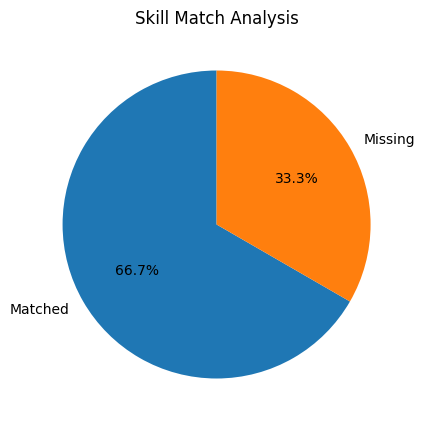

In [97]:
import matplotlib.pyplot as plt

matched_count = len(matched)
missing_count = len(missing)

plt.figure(figsize=(5,5))

plt.pie(
    [matched_count, missing_count],
    labels=["Matched", "Missing"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Skill Match Analysis")

plt.savefig(
    "images/skill_match_pie.png",
    dpi=300
)

plt.show()

In [98]:
print("=" * 50)

print("AI RESUME ANALYSIS REPORT")

print("=" * 50)

print("Candidate:", resume_result["Name"])

print("ATS Score:", ats_result["Final ATS Score"])

print("Semantic Similarity:", semantic_score)

print("\nMatched Skills:")
print(", ".join(matched))

print("\nMissing Skills:")
print(", ".join(missing))

print("\nSuggestions:")

for s in suggestions:
    print("•", s)

AI RESUME ANALYSIS REPORT
Candidate: Kanan Mundra
ATS Score: 71.46
Semantic Similarity: 47.12

Matched Skills:
Machine Learning, Power Bi, Python, Sql

Missing Skills:
Aws, Docker

Suggestions:
• Improve your ATS score by aligning your resume with the job description.
• Add projects or experience demonstrating: Aws, Docker
• Quantify your achievements (e.g., 'Improved model accuracy by 15%' or 'Reduced processing time by 30%').
• Use action verbs such as Developed, Built, Designed, Implemented, Optimized, and Automated.


In [99]:
!pip install rapidfuzz


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
from src.weighted_skill_matcher import WeightedSkillMatcher

result = WeightedSkillMatcher.match_skills(

    resume_result["Skills"],

    jd_result["Skills"]

)

result

{'Matched': [{'JD Skill': 'Machine Learning',
   'Resume Skill': 'Machine Learning',
   'Similarity': 100.0},
  {'JD Skill': 'Power Bi', 'Resume Skill': 'Power Bi', 'Similarity': 100.0},
  {'JD Skill': 'Python', 'Resume Skill': 'Python', 'Similarity': 100.0},
  {'JD Skill': 'Sql', 'Resume Skill': 'Sql', 'Similarity': 100.0}],
 'Missing': ['Aws', 'Docker'],
 'Skill Score': 60.0}

In [101]:
print("Missing Skills")

for skill in ats_result["Missing Skills"]:

    print("•", skill)

Missing Skills
• Aws
• Docker


In [102]:
from src.section_analyzer import ResumeSectionAnalyzer

section_result = ResumeSectionAnalyzer.analyze(

    resume_result["Raw Text"]

)

section_result

{'Detected Sections': {'Summary': True,
  'Skills': True,
  'Experience': True,
  'Projects': True,
  'Education': True,
  'Certifications': False,
  'Achievements': True,
  'Languages': True},
 'Section Score': 87.5,
 'Missing Sections': ['Certifications']}

In [103]:
print("="*60)

print("RESUME SECTION ANALYSIS")

print("="*60)

for section, status in section_result["Detected Sections"].items():

    if status:
        print(f"✅ {section}")

    else:
        print(f"❌ {section}")

print("\n")

print("Section Score:", section_result["Section Score"])

print("\nMissing Sections")

for sec in section_result["Missing Sections"]:

    print("•", sec)

RESUME SECTION ANALYSIS
✅ Summary
✅ Skills
✅ Experience
✅ Projects
✅ Education
❌ Certifications
✅ Achievements
✅ Languages


Section Score: 87.5

Missing Sections
• Certifications


In [104]:
from src.explainable_ats import ExplainableATS

feedback = ExplainableATS.generate_feedback(

    ats_result,

    section_result

)

for line in feedback:

    print("•", line)

• Your resume is missing several important skills required by the job.
• Resume content is not sufficiently aligned with the Job Description.
• Resume is mostly complete but can be improved.
• Missing Skills: Aws, Docker
• Missing Resume Sections: Certifications


In [105]:
print("="*70)
print("AI ATS ANALYSIS REPORT")
print("="*70)

print()

print("Final ATS Score :", ats_result["Final ATS Score"])
print("Skill Match     :", ats_result["Skill Match"])
print("Similarity      :", ats_result["Semantic Similarity"])

print()

print("Matched Skills")

for s in ats_result["Matched Skills"]:

    print("✓", s)

print()

print("Missing Skills")

for s in ats_result["Missing Skills"]:

    print("✗", s)

print()

print("Resume Feedback")

for f in feedback:

    print("•", f)

AI ATS ANALYSIS REPORT

Final ATS Score : 71.46
Skill Match     : 60.0
Similarity      : 51.79

Matched Skills
✓ {'JD Skill': 'Machine Learning', 'Resume Skill': 'Machine Learning', 'Similarity': 100.0}
✓ {'JD Skill': 'Power Bi', 'Resume Skill': 'Power Bi', 'Similarity': 100.0}
✓ {'JD Skill': 'Python', 'Resume Skill': 'Python', 'Similarity': 100.0}
✓ {'JD Skill': 'Sql', 'Resume Skill': 'Sql', 'Similarity': 100.0}

Missing Skills
✗ Aws
✗ Docker

Resume Feedback
• Your resume is missing several important skills required by the job.
• Resume content is not sufficiently aligned with the Job Description.
• Resume is mostly complete but can be improved.
• Missing Skills: Aws, Docker
• Missing Resume Sections: Certifications


In [106]:
from src.resume_improver import ResumeImprover

suggestions = ResumeImprover.generate_suggestions(

    ats_result,

    section_result,

    resume_result,

    jd_result

)

for s in suggestions:

    print("•", s)

• Add these missing skills: Aws, Docker
• Add a 'Certifications' section to your resume.
• Add your LinkedIn profile.
• Add your GitHub profile.


In [107]:
from src.bullet_rewriter import ResumeBulletRewriter

rewrites = ResumeBulletRewriter.rewrite(

    resume_result["Raw Text"]

)

len(rewrites)

44

In [108]:
for item in rewrites[:5]:

    print("="*80)

    print("Original")

    print(item["Original"])

    print()

    print("Improved")

    print(item["Improved"])

    print()

Original
+91-8824235688 — kananmundra06@gmail

Improved
+91-8824235688 — kananmundra06@gmail resulting in measurable business impact.

Original
com — LinkedIn — GitHub

Improved
com — LinkedIn — GitHub resulting in measurable business impact.

Original
Professional Summary

Improved
Professional Summary resulting in measurable business impact.

Original
Aspiring Data Scientist pursuing a B

Improved
Aspiring Data Scientist pursuing a B resulting in measurable business impact.

Original
Tech in Computer Science with expertise in Machine Learning, Data Analytics, Natural

Improved
Tech in Computer Science with expertise in Machine Learning, Data Analytics, Natural resulting in measurable business impact.



In [109]:
from src.gap_analysis import GapAnalyzer

gap = GapAnalyzer.analyze(

    ats_result,

    section_result,

    resume_result,

    jd_result

)

In [110]:
print("="*70)

print("RESUME vs JOB DESCRIPTION REPORT")

print("="*70)

print()

print("Job Role :", gap["Job Role"])

print()

print("ATS Score :", gap["ATS Score"])

print()

print("Matched Skills")

for skill in gap["Matched Skills"]:

    print("✓", skill)

print()

print("Missing Skills")

for skill in gap["Missing Skills"]:

    print("✗", skill)

print()

print("Resume Experience :", gap["Resume Experience"])

print("Required Experience :", gap["Required Experience"])

print("Status :", gap["Experience Status"])

print()

print("Education :", gap["Education Status"])

print()

print("Present Sections")

for sec in gap["Present Sections"]:

    print("✓", sec)

print()

print("Missing Sections")

for sec in gap["Missing Sections"]:

    print("✗", sec)

print()

print("Suggestions")

for suggestion in gap["Suggestions"]:

    print("•", suggestion)

print()

print("Estimated ATS After Improvements :", gap["Estimated ATS"])

RESUME vs JOB DESCRIPTION REPORT

Job Role : Data Scientist

ATS Score : 71.46

Matched Skills
✓ {'JD Skill': 'Machine Learning', 'Resume Skill': 'Machine Learning', 'Similarity': 100.0}
✓ {'JD Skill': 'Power Bi', 'Resume Skill': 'Power Bi', 'Similarity': 100.0}
✓ {'JD Skill': 'Python', 'Resume Skill': 'Python', 'Similarity': 100.0}
✓ {'JD Skill': 'Sql', 'Resume Skill': 'Sql', 'Similarity': 100.0}

Missing Skills
✗ Aws
✗ Docker

Resume Experience : 0
Required Experience : 2
Status : Acceptable for Freshers

Education : Matched

Present Sections
✓ Summary
✓ Skills
✓ Experience
✓ Projects
✓ Education
✓ Achievements
✓ Languages

Missing Sections
✗ Certifications

Suggestions
• Add skill: Aws
• Add skill: Docker
• Add section: Certifications
• Add GitHub profile
• Add LinkedIn profile

Estimated ATS After Improvements : 81.46


In [111]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install reportlab

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
